Todos os códigos presentes estão disponíveis em: https://github.com/Dhonrian/pos_ifnet/blob/main/25E4_3/validacao.ipynb

### Para esta matéria será utilizado o mesmo ambiente de clusterização
<img src="resources/env.png">

### Dataset
O dataset escolhido foi um retirado do https://www.kaggle.com/datasets/umuttuygurr/city-lifestyle-segmentation-dataset/, que indica o estilo de vida de aproximadamente 300 cidades.

O objetivo é agrupar cidades semelhantes baseadas nas caracteristicas economicas, ambientais etc.

As features presentes são:

|Coluna|Tipo|Descrição|
|------|----|---------|
|city_name|string|Nome da cidade|
|country|string|Região em que a cidade é localizada|
|population_density|int|População por km²|
|avg_income|float|Média do salário em dólar|
|internet_penetration|float|Porcentagem de casas com acesso a internet|
|avg_rent|float|Média do aluguel de um apartamento|
|air_quality_index|int|Indíce de qualidade do ar (menor = melhor)|
|public_transport_score|float|Qualidade do transporte público|
|happiness_score|float|Valor entre 0-10 subjetivo de satisfação com a vida|
|green_space_ratio|float|Porcentagem da cidade coberta por parques/áreas verdes|

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances_argmin_min
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import numpy as np

In [196]:
original_df = pd.read_csv('city_lifestyle_dataset.csv')

In [197]:
original_df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [198]:
original_df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


In [199]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


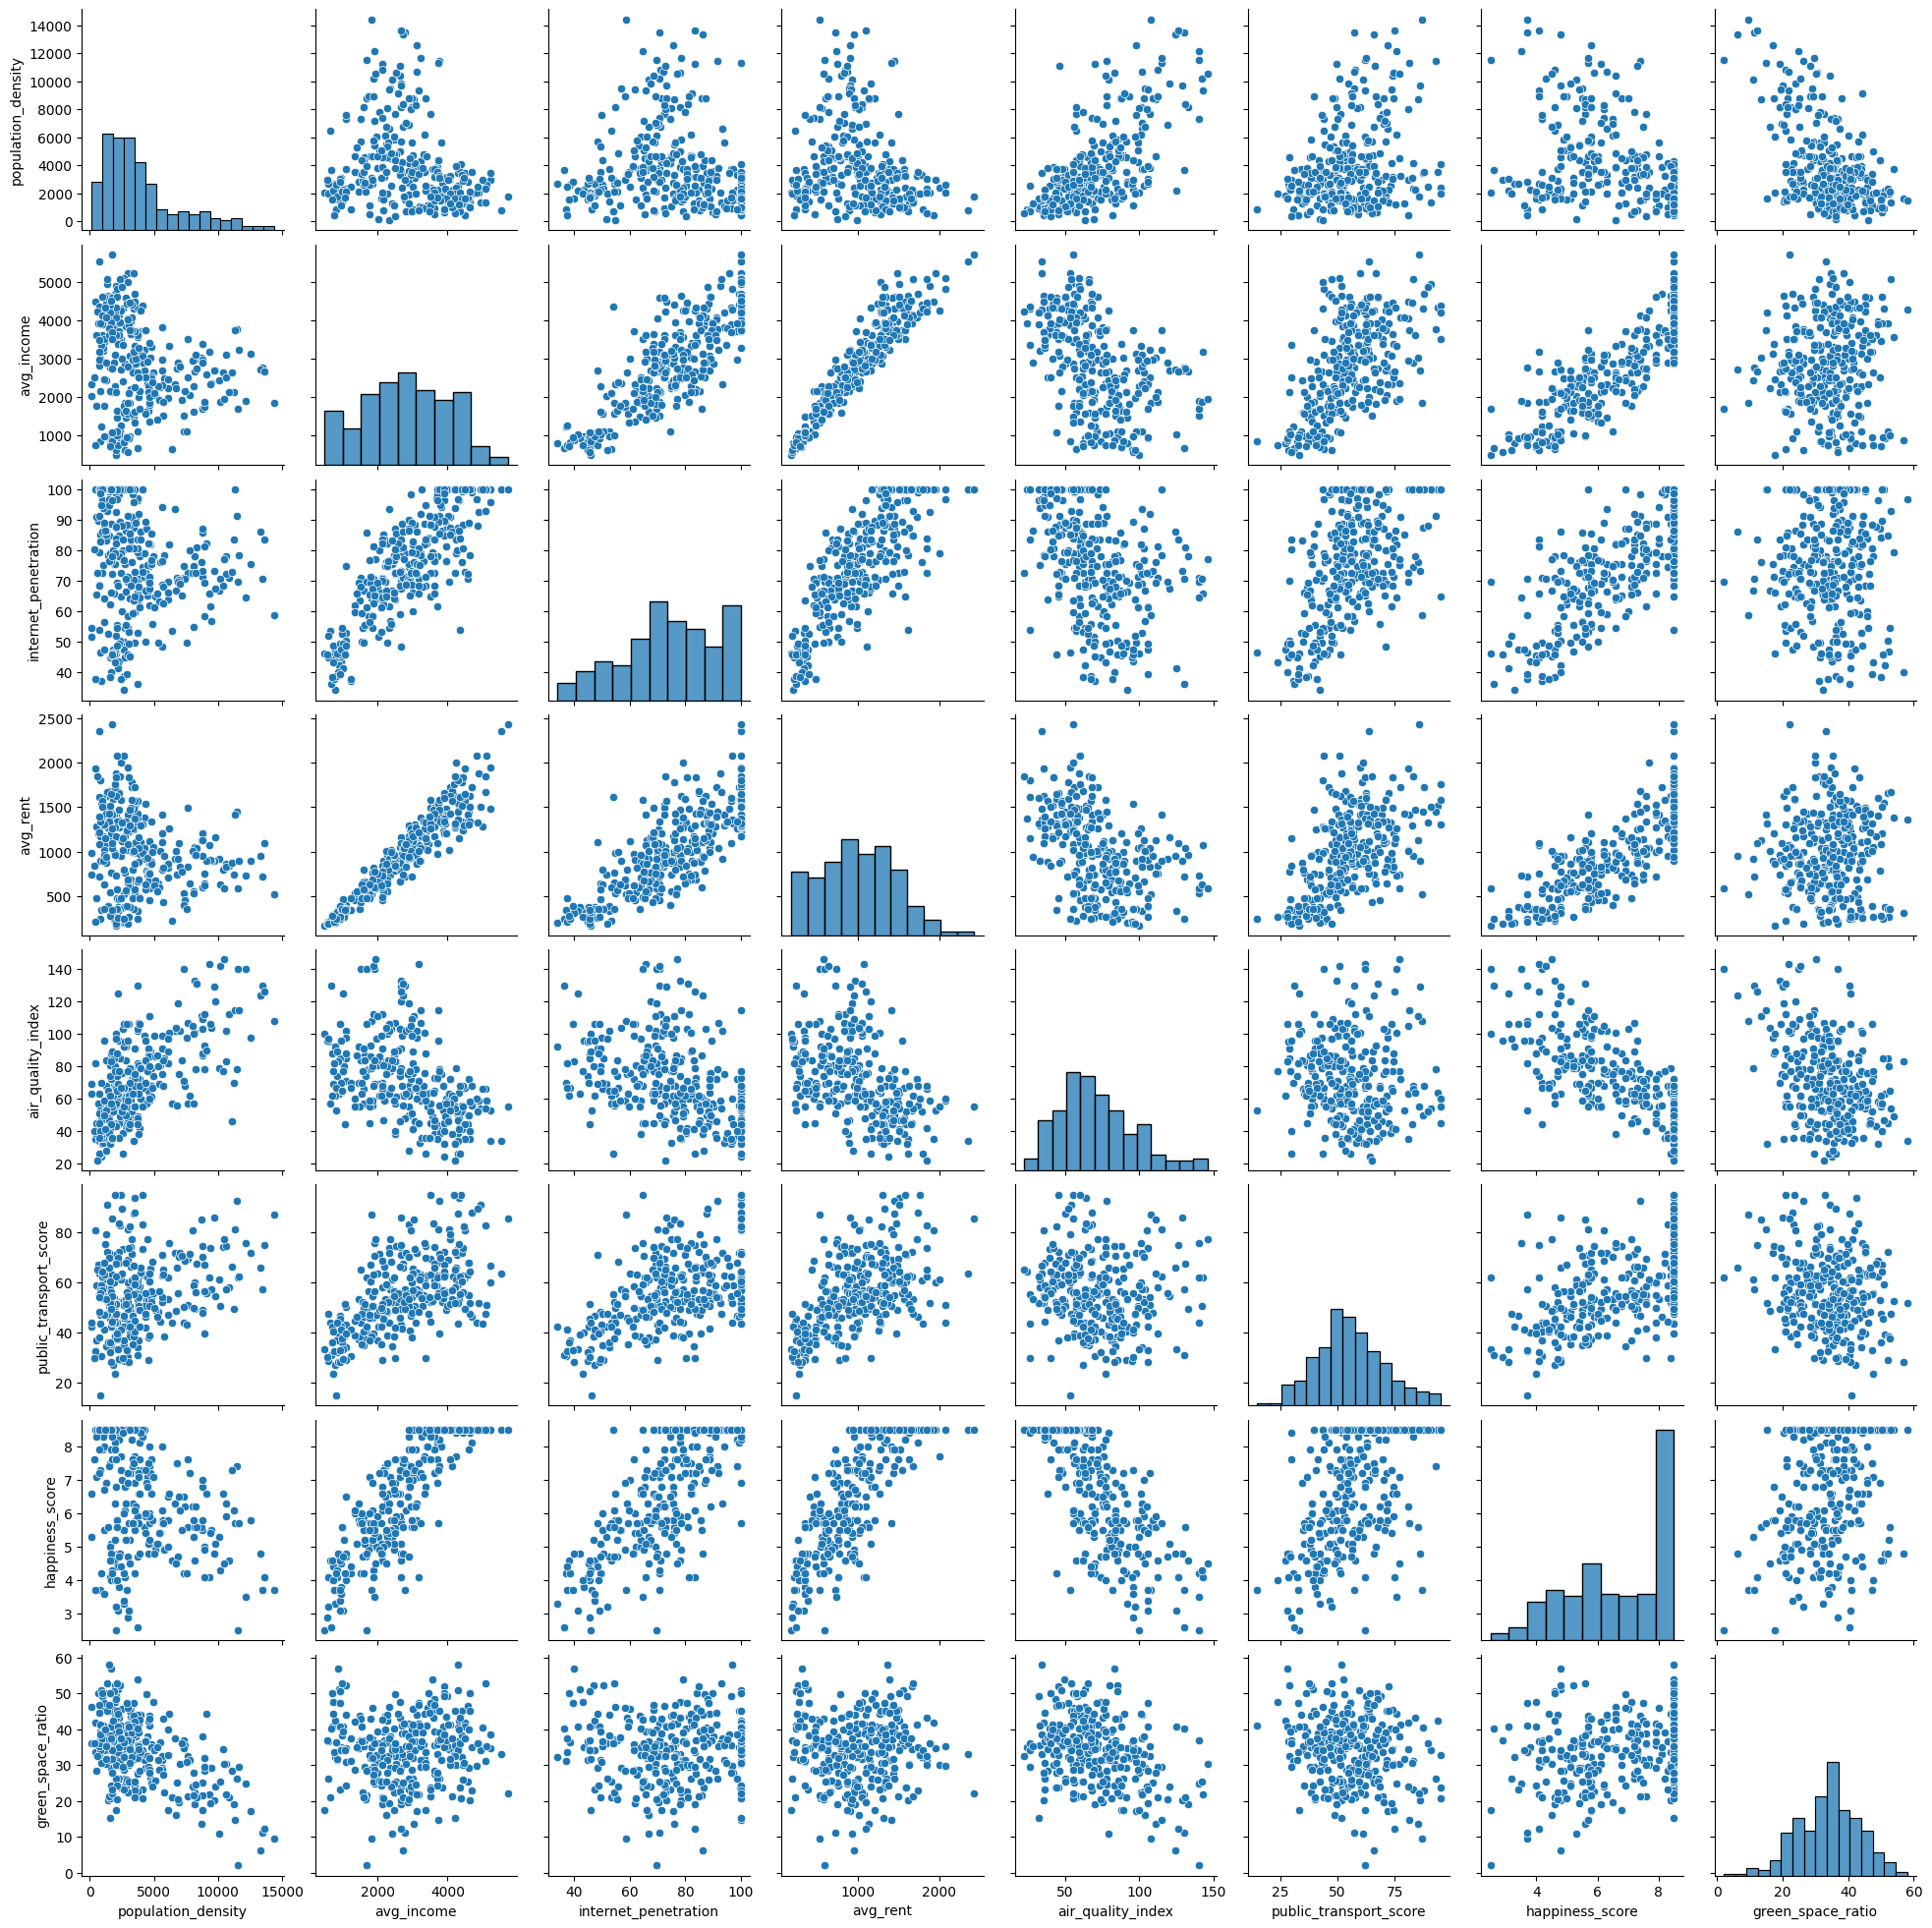

In [200]:
sns.pairplot(original_df)

## Pré processamento

In [201]:
categorical_cols = original_df.select_dtypes(include=['object','category']).columns.tolist()
numerical_cols   = original_df.select_dtypes(include=['int64','float64']).columns.tolist()

In [202]:
print("Categóricas:", categorical_cols)
print("Numéricas:", numerical_cols)

Categóricas: ['city_name', 'country']
Numéricas: ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']


In [203]:
df = original_df.drop(columns=categorical_cols)

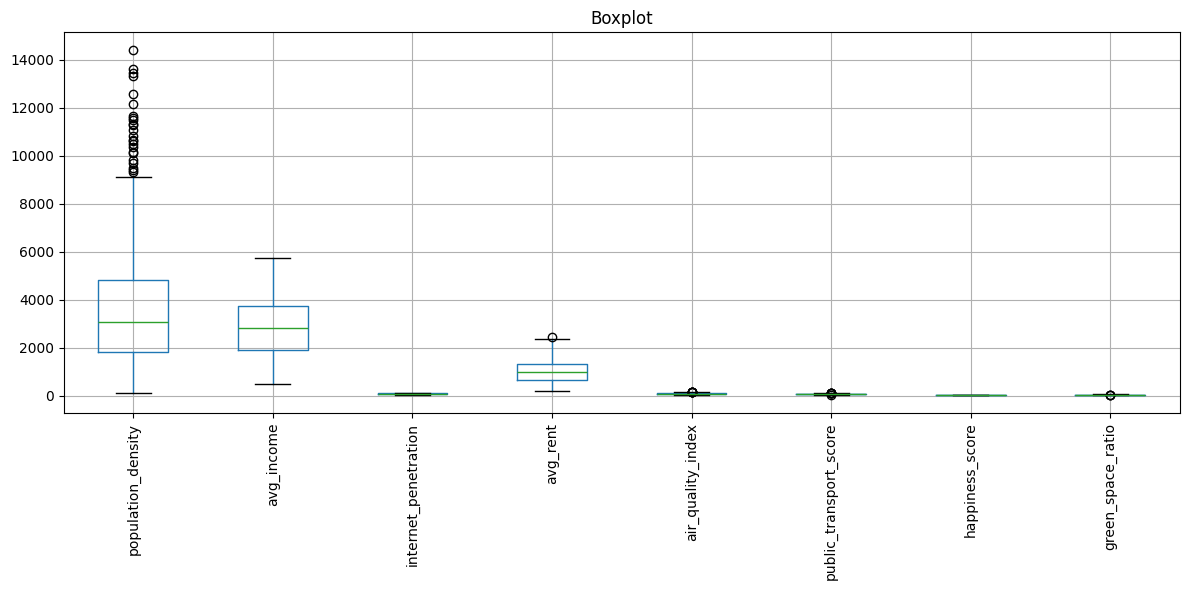

In [204]:
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplot")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

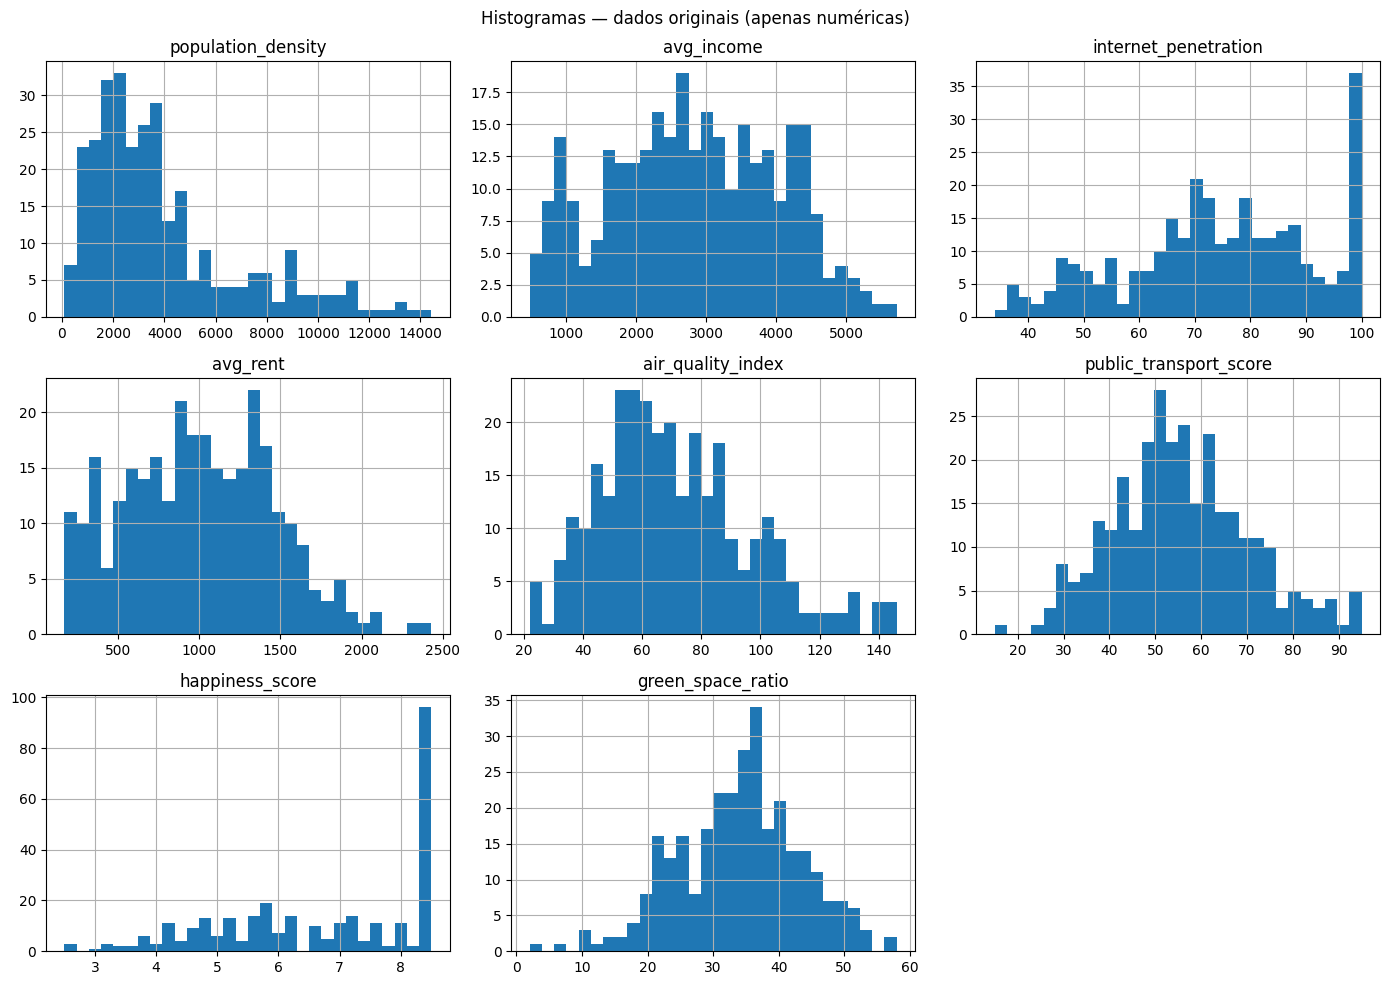

In [205]:
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Histogramas — dados originais (apenas numéricas)")
plt.tight_layout()
plt.show()

Existe uma diferença de escala nos dados então iremos deixar todos na mesma faixa usando o StandardScaler

In [206]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled, columns=df.columns)
scaled_df[categorical_cols] = original_df[categorical_cols]

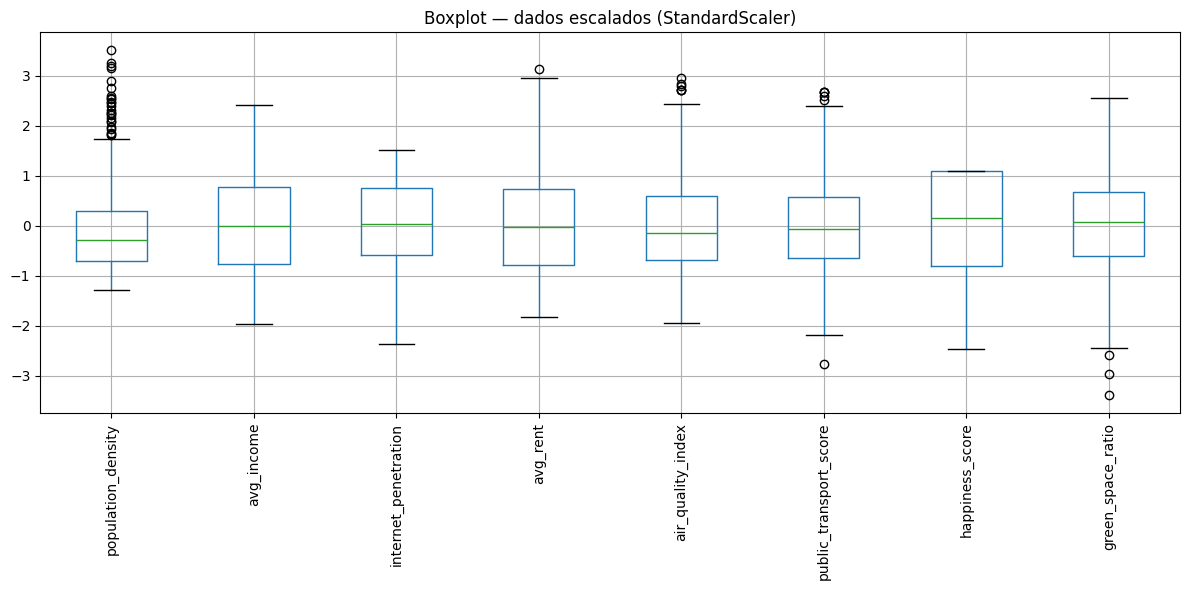

In [207]:
plt.figure(figsize=(12, 6))
scaled_df.boxplot()
plt.title("Boxplot — dados escalados (StandardScaler)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

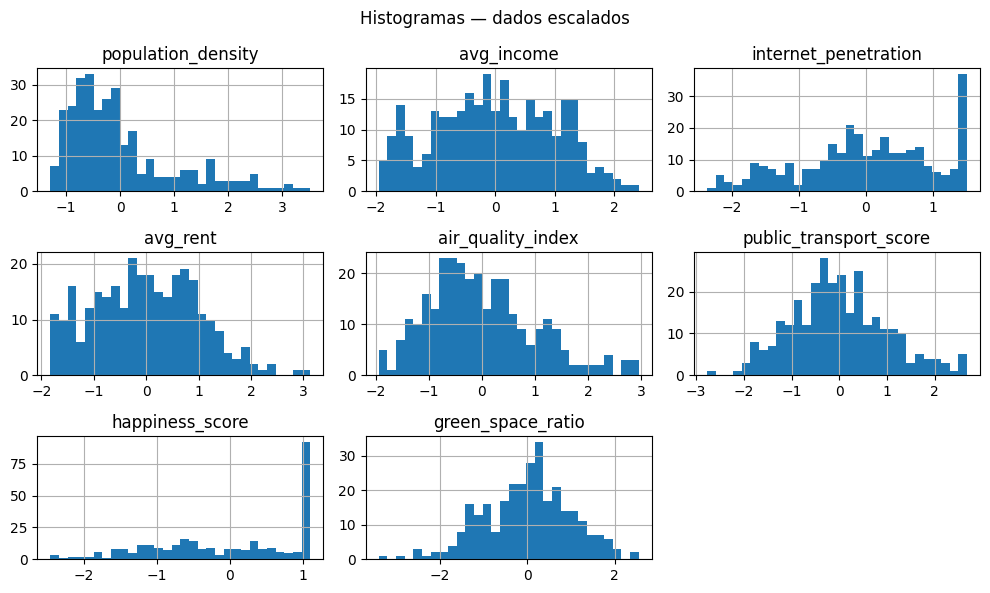

In [208]:
scaled_df.hist(figsize=(10, 6), bins=30)
plt.suptitle("Histogramas — dados escalados")
plt.tight_layout()
plt.show()

In [209]:
pca = PCA(n_components=2, random_state=10)
X_pca = pca.fit_transform(scaled_df.drop(columns=categorical_cols))

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})

In [210]:
N_CLUSTERS = 3 #número padrão por enquanto
SEED = 10
X = scaled_df.drop(columns=categorical_cols)

In [211]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED).fit(X)
pca_df["kmeans_cluster"] = kmeans.labels_

dbscan = DBSCAN(eps=0.02, min_samples=5).fit(X)
pca_df['db_cluster'] = dbscan.labels_

<Axes: xlabel='PC1', ylabel='PC2'>

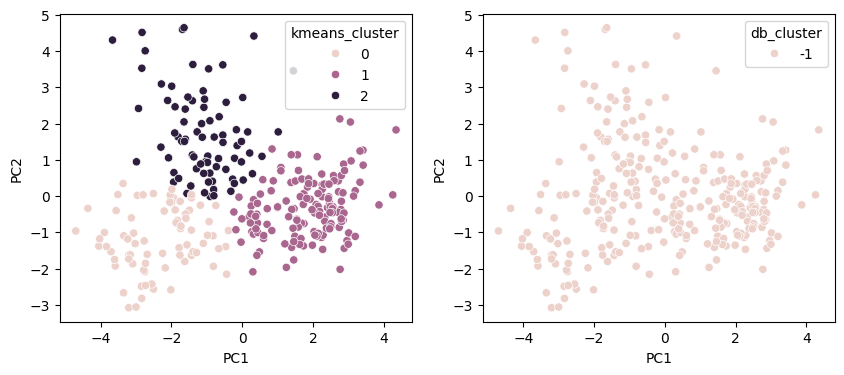

In [212]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", ax=ax[0], hue='kmeans_cluster')
sns.scatterplot(data=pca_df, x="PC1", y="PC2", ax=ax[1], hue='db_cluster')

O resultado do kmeans para 3 clusters ficou relativamente ok apesar de existir alguns dados misturados. 
Já o DBScan padrão identificou todos os pontos como ruído.

Usando o Silhouete Score com diferentes parâmetros descobriremos o melhor número de clusters e de min_eps e min_samples para gerar melhores resultados

In [213]:
kmeans_range = range(2, 11)
silhouete_scores = []

for k in kmeans_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, init='k-means++').fit(X)
    labels = kmeans.labels_
    silhouette = silhouette_score(X, labels)
    silhouete_scores.append(silhouette)

As heuristicas para o DBScan são as seguintes:
- 1 -> d <= 2 -> min_sample = 4
- 2 -> d > 2 -> min_sample = 2*d
- 3 -> n >= 1000 -> min_sample = ln(n)
- 4 -> testar valores entre [3, 2*d]

Como o dataset possui 8 features e menos que 1000 linhas, iremos testar o espaço entre 3 e 16 (2*8) para o min_samples

In [214]:
min_samples_range = range(3, scaled_df.shape[1] + 1)
best_min_samples = None
best_score = -1

for min_samples in min_samples_range:
    dbscan_model = DBSCAN(eps=0.5, min_samples=min_samples).fit(X)
    labels = dbscan_model.labels_

    if len(set(labels)) > 1:
        score = silhouette_score(X, labels)

        print('Min_samples:', min_samples)
        print('Score:', score)
        print('-----------------------------------')

        if score > best_score:
            best_score = score
            best_min_samples = min_samples

print(f'Melhor min_samples: {best_min_samples}')
print(f'Melhor score: {best_score}')

Min_samples: 3
Score: -0.23207710764816913
-----------------------------------
Melhor min_samples: 3
Melhor score: -0.23207710764816913


Para encontrar o melhor eps iremos usar o KNN para encontrar o número ideal de vizinhos próximos. Como o min_samples ficou negativo iremos variar os 2 parâmetros ao mesmo tempo

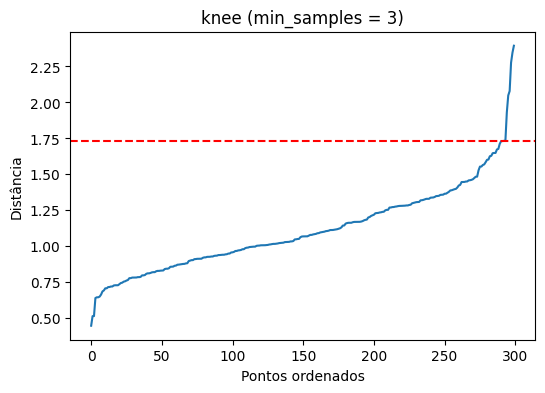

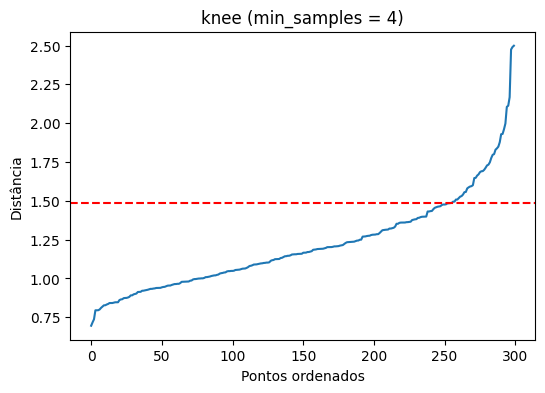

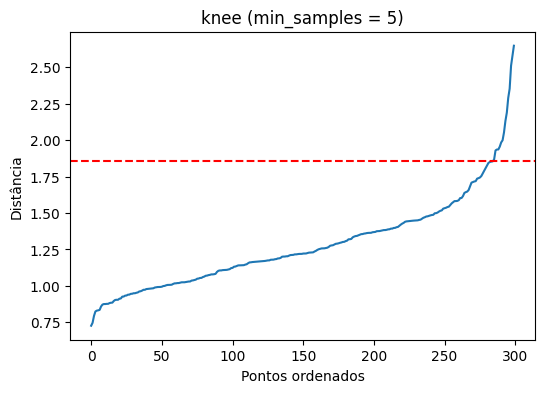

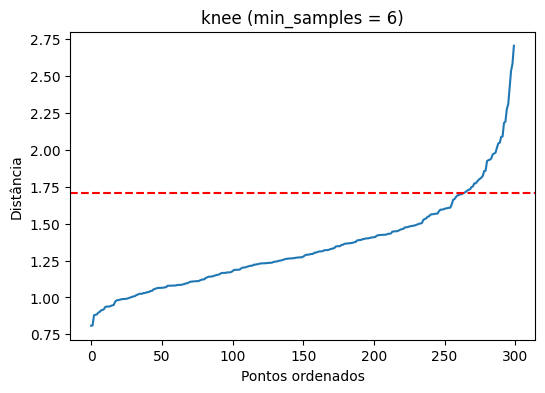

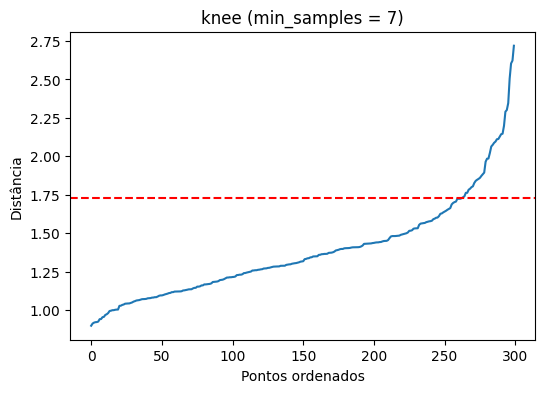

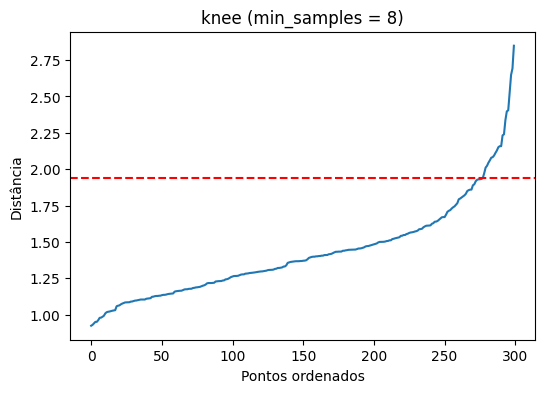

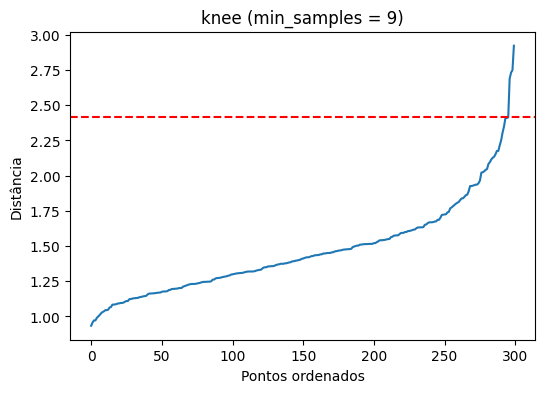

[(3, np.float64(1.7344952526609974)),
 (4, np.float64(1.4863090346479086)),
 (5, np.float64(1.85448539238938)),
 (6, np.float64(1.7094556468939004)),
 (7, np.float64(1.7278989632840969)),
 (8, np.float64(1.9391012514636041)),
 (9, np.float64(2.415042541802217))]

In [215]:
min_samples_list = range(3, scaled_df.shape[1])

eps_list = []

for min_s in min_samples_list:

    neigh = NearestNeighbors(n_neighbors=min_s)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)

    k_distance = np.sort(distances[:, -1])

    kneedle = KneeLocator(
        range(len(k_distance)),
        k_distance,
        S=1.0,
        curve="convex",
        direction="increasing",
    )

    eps = k_distance[kneedle.knee] if kneedle.knee is not None else None
    eps_list.append((min_s, eps))

    plt.figure(figsize=(6,4))
    plt.plot(k_distance)
    if eps is not None:
        plt.axhline(eps, color='red', linestyle='--')
    plt.title(f"knee (min_samples = {min_s})")
    plt.xlabel("Pontos ordenados")
    plt.ylabel("Distância")
    plt.show()

eps_list

In [216]:
best_score = -1
best_eps = None
best_min_samples = None

silhouete_db = [] 

for min_s, base_eps in eps_list:
    if base_eps is None:
        silhouete_db.append(-1)  
        continue

    eps_range = np.linspace(base_eps*0.8, base_eps*1.2, 10)

    best_score_for_this_min_samples = -1  

    for eps in eps_range:

        db = DBSCAN(eps=eps, min_samples=min_s).fit(X)
        labels = db.labels_

        if len(set(labels)) <= 1 or set(labels) == {-1}:
            continue

        score = silhouette_score(X, labels)

        if score > best_score_for_this_min_samples:
            best_score_for_this_min_samples = score

    silhouete_db.append(best_score_for_this_min_samples)

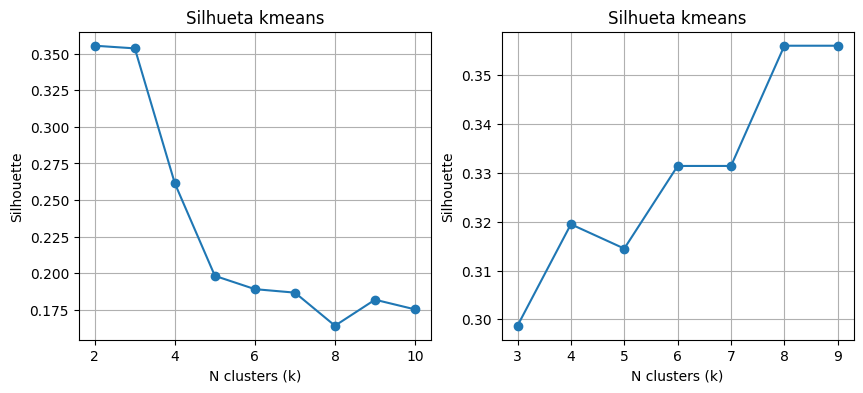

In [217]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(kmeans_range, silhouete_scores, marker='o')
ax[0].set_title("Silhueta kmeans")
ax[0].set_xlabel("N clusters (k)")
ax[0].set_ylabel("Silhouette")
ax[0].grid(True)

ax[1].plot(min_samples_list, silhouete_db, marker='o')
ax[1].set_title("Silhueta kmeans")
ax[1].set_xlabel("N clusters (k)")
ax[1].set_ylabel("Silhouette")
ax[1].grid(True)


plt.show()

De acordo com o score da silhueta os números mais próximos de 1 são os melhores para os clusters.
Plotando com o número de clusters

In [218]:
eps_list

[(3, np.float64(1.7344952526609974)),
 (4, np.float64(1.4863090346479086)),
 (5, np.float64(1.85448539238938)),
 (6, np.float64(1.7094556468939004)),
 (7, np.float64(1.7278989632840969)),
 (8, np.float64(1.9391012514636041)),
 (9, np.float64(2.415042541802217))]

In [219]:
best_kmeans = KMeans(n_clusters=2, random_state=SEED).fit(X)
pca_df['best_kmeans'] = best_kmeans.labels_

best_dbscan = DBSCAN(min_samples=6, eps=1.7094556468939004).fit(X)
pca_df['best_dbscan'] = best_dbscan.labels_

<Axes: xlabel='PC1', ylabel='PC2'>

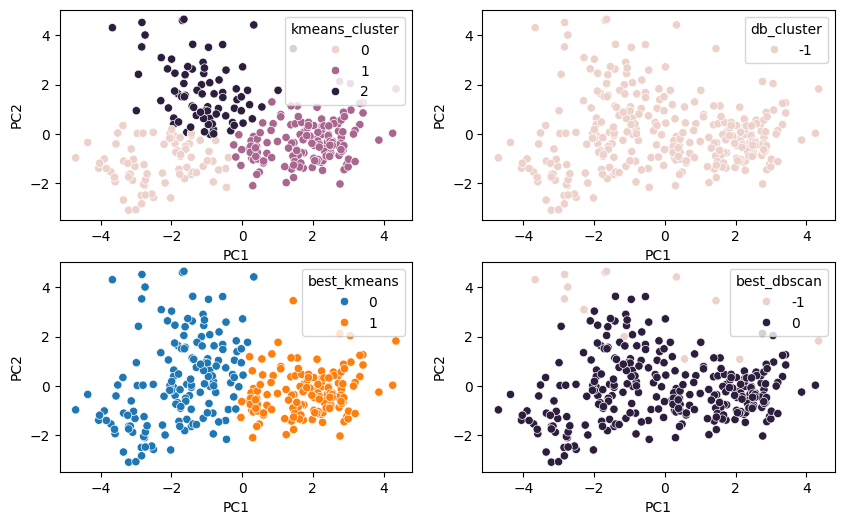

In [220]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='kmeans_cluster', ax=ax[0][0])
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='db_cluster', ax=ax[0][1])
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='best_kmeans', ax=ax[1][0])
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='best_dbscan', ax=ax[1][1])


Para o dataset escoliho o DBScan não consegue identificar muito bem os clusters.  
Os dados tem uma alta densidade e não existem zonas com baixa densidade para o algoritimo fazer essa diferenciação.

Outras métricas possíveis usar para o KMeans são o WSS, DBI e CHI.
Todas ajudam a determinar o melhor número de clusters 

In [221]:
kmeans_range = range(2, 11)

sil_k = []
wss_k = []
dbi_k = []
chi_k = []

for k in kmeans_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED).fit(X)
    labels = kmeans.labels_

    sil_k.append(silhouette_score(X, labels))
    wss_k.append(kmeans.inertia_)
    dbi_k.append(davies_bouldin_score(X, labels))
    chi_k.append(calinski_harabasz_score(X, labels))

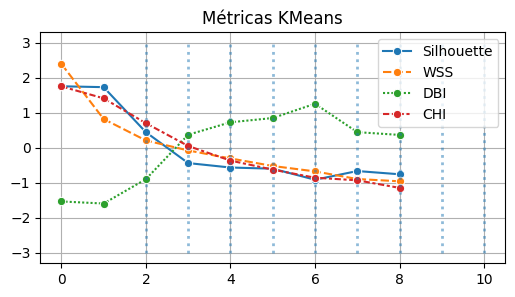

In [222]:
k = list(kmeans_range)
df_metrics = pd.DataFrame({
    "Silhouette": sil_k,
    "WSS": wss_k,
    "DBI": dbi_k,
    "CHI": chi_k
})


results_scaled_df = StandardScaler().fit_transform(df_metrics)
results_scaled_df = pd.DataFrame(results_scaled_df, columns=df_metrics.columns, index=df_metrics.index)
results_scaled_df

f, ax = plt.subplots(figsize=(6, 3))
sns.lineplot(data=results_scaled_df, marker="o")

for k in kmeans_range:
    ax.vlines(k, -3, 3, linestyles=':', linewidth=2, alpha=0.5)


plt.title("Métricas KMeans")
plt.grid(True)
plt.show()

Comparando todos os resultados um bom número de cluster parece ser entre 2-4.   
Clusters nesse formato ficam da seguinte maneira:


/home/leo/.pyenv/versions/cluster/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/leo/.pyenv/versions/cluster/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/leo/.pyenv/versions/cluster/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


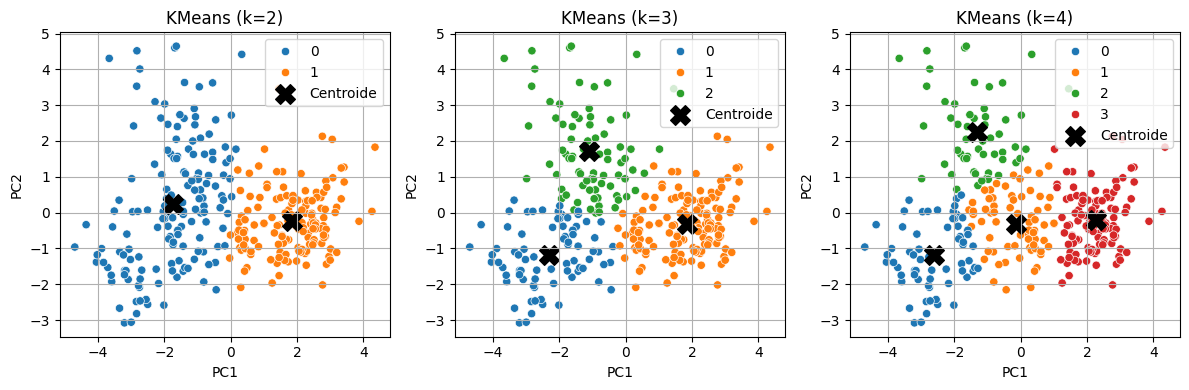

-------
Cluster 0: país mais próximo = South America (Hillshire)
Cluster 1: país mais próximo = Europe (Woodport)
-------
Cluster 0: país mais próximo = Africa (Parkburg)
Cluster 1: país mais próximo = Europe (Woodport)
Cluster 2: país mais próximo = Asia (Lake Bay)
-------
Cluster 0: país mais próximo = Africa (Parkburg)
Cluster 1: país mais próximo = Asia (Ridgeford)
Cluster 2: país mais próximo = Asia (Lake Bay)
Cluster 3: país mais próximo = Europe (Woodport)


In [231]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

centroids_list = []

for k in range(2, 5):

    # ----- KMEANS -----
    kmeans = KMeans(n_clusters=k, random_state=SEED).fit(X)
    pca_df["cluster"] = kmeans.labels_

    # ----- CENTRÓIDES EM PCA -----
    centroids = kmeans.cluster_centers_
    centroids_pca = pca.transform(centroids)

    # ----- SCATTER -----
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="cluster",
        palette="tab10",
        ax=ax[k-2]
    )

    # PLOTA CENTRÓIDES
    ax[k-2].scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        c="black",
        s=200,
        marker="X",
        label="Centroide"
    )

    ax[k-2].set_title(f"KMeans (k={k})")
    ax[k-2].legend()
    ax[k-2].grid(True)

    # ----- ENCONTRA O PAÍS MAIS PRÓXIMO DO CENTRÓIDE -----
    nearest_countries = []

    for i in range(k):
        centroid = centroids[i]

        # calcula distância de TODOS os pontos ao centróide
        distances = np.linalg.norm(X.values - centroid, axis=1)

        # índice do menor valor
        idx_min = distances.argmin()

        # pega país e região do scaled_df
        country = scaled_df.iloc[idx_min]["country"]
        region = scaled_df.iloc[idx_min]["city_name"]

        nearest_countries.append((i, country, region))

    centroids_list.append((k, nearest_countries))

plt.tight_layout()
plt.show()

for k, countries in centroids_list:
    print("-------")
    for cluster_id, country, region in countries:
        print(f"Cluster {cluster_id}: país mais próximo = {country} ({region})")


O número ideal de Cluster depende da análise a ser feita.  

- Com 2 clusters pode se alegar que está comparando grandes grupos distintos; cidades com maior desenvolvimento vs cidades com menor desenvolvimento.  
- 3 Clusters agrupa cidades que não se encaixam nos extremos; pode indicar 3 estilos de vida diferentes.
- E por ultimo 4 cluster, pode separar cidades com perfis mais detalhados; população e qualidade do ar parecidos por exemplo

## Medidas de Similaridade

1 - Um determinado problema, apresenta 10 séries temporais distintas. Gostaríamos de agrupá-las em 3 grupos, de acordo com um critério de similaridade, baseado no valor máximo de correlação cruzada entre elas. Descreva em tópicos todos os passos necessários.

R: 
    - A correlação cruzada é baseada no número de "lags" ou atrasos entre as séries temporáis.
    - Para cada ponto é calculado a correlação de pearson extraído o maior valor.
    - Com o maior valor é montado uma matriz.
    - Com a matriz montada é possível utilizar o agrupamento aglomerativo por exemplo para montar uma clusterização hierarquica para montar um dendograma das séries que mais se parecem. 
    - Com o dendograma é possível fazer um corte que cruze exatamente 3 linhas, extraindo assim os 3 grupos.

2- Para o problema da questão anterior, indique qual algoritmo de clusterização você usaria. Justifique.
R: Como o dendograma funciona através das semelhanças entre as variáveis presentes ele é o algoritmo que mais se encaixa no problema. O dendongrama funciona como um cladograma da biologia, que faz referência ao ancestral comum entre duas espécies. Logo a visualização das séries que são mais próximas se torna mais intuitiva.

3- Indique um caso de uso para essa solução projetada.
R: Um caso de uso clássico para séries temporais é para detectar falha em máquinas através de medidas de sensores. O dendograma pode indicar máquinas que possuem padrões iguais ao longo do tempo.

4- Sugira outra estratégia para medir a similaridade entre séries temporais. Descreva em tópicos os passos necessários.
R: Outra estratégia para medir a similaridade em séries temporáis é utilizar o Dynamic Time Warping (DTW) que funciona da seguinte maneira:
    - Escolher os parâmetros que vão ser comparados.
    - Calcular a distancia entre os pontos das séries.
    - Montar a matriz de distância entre os pontos.
    - Por fim realizar o agrupamento.

